### Hyperparameter Tuning using Random Search for NAMs

In [ ]:
import json
import os
from pathlib import Path

# Options for DATASET_TYPE: "synthetic" or "openml"
DATASET_TYPE = "synthetic"

# For synthetic datasets (when DATASET_TYPE == "synthetic"):
SYNTHETIC_TYPE = "nonlinear"  # Options: "linear" or "nonlinear"

# For OpenML datasets (when DATASET_TYPE == "openml"):
OPENML_DATASET_ID = 37  # OpenML dataset ID (e.g., 37, 1461, etc.)
TASK_TYPE = "classification"  # Options: "classification" or "regression"

In [ ]:
from hp_tuning_utils import load_hp_tuning_conf

# Load configuration based on dataset type
if DATASET_TYPE == "openml":
    if TASK_TYPE == "classification":
        CONF_PATH = Path('hp_tuning_conf/openml_classification.json')
    else:
        CONF_PATH = Path('hp_tuning_conf/openml_regression.json')
    
    # Load config and replace <id> placeholder with actual dataset ID
    hp_search_space, fixed_hp = load_hp_tuning_conf(CONF_PATH)
    fixed_hp['dataset_name'] = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
    print(f"Loaded OpenML config: {CONF_PATH}")
    print(f"Dataset: OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}")
else:
    # Load synthetic dataset config (linear or nonlinear)
    if SYNTHETIC_TYPE == "linear":
        CONF_PATH = Path('hp_tuning_conf/correlated_linear.json')
    else:  # nonlinear
        CONF_PATH = Path('hp_tuning_conf/correlated_nonlinear.json')
    
    hp_search_space, fixed_hp = load_hp_tuning_conf(CONF_PATH)
    print(f"Loaded synthetic dataset config: {CONF_PATH}")
    print(f"Dataset: {fixed_hp.get('dataset_name', f'Correlated_{SYNTHETIC_TYPE}')}")
    print(f"Synthetic type: {SYNTHETIC_TYPE}")

print(f"Task type: {'Regression' if fixed_hp.get('regression', False) else 'Classification'}")


Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
# Random search parameters
n_trials = 50
random_seed = 42

# Set base_logdir based on dataset type
if DATASET_TYPE == "openml":
    base_logdir = f'./hp_tuning_openml_{OPENML_DATASET_ID}_{TASK_TYPE}'
else:
    dataset_name = fixed_hp.get('dataset_name', 'correlated_nonlinear').lower().replace(' ', '_')
    base_logdir = f'./hp_tuning_{dataset_name}'

os.makedirs(base_logdir, exist_ok=True)
print(f"Results will be saved to: {base_logdir}")

In [4]:
from hp_tuning_utils import sample_hyperparameters

hyperparameters = []

for trial in range(n_trials):
    trial_seed = random_seed + trial
    hp_config = sample_hyperparameters(hp_search_space, trial_seed)
    trial_num = trial + 1
    
    hyperparameters.append({
        'trial': trial_num,
        'hyperparameters': hp_config.copy()
    })


In [5]:
from hp_tuning_utils import run_trials

# Run settings
num_splits = fixed_hp['num_splits']
trials_to_run = range(1, n_trials + 1)
skip_if_exists = False
per_split_timeout_s = 3600

run_trials(
    fixed_hp=fixed_hp,
    hyperparameters=hyperparameters,
    base_logdir=base_logdir,
    n_trials=n_trials,
    num_splits=num_splits,
    trials_to_run=trials_to_run,
    skip_if_exists=skip_if_exists,
    per_split_timeout_s=per_split_timeout_s,
)



=== Trial 1/50 ===
Running split 1/1 for trial 1...
  Completed in 157.7s (success=True)
Saved: ./hp_tuning_correlated_nonlinear\trial_1_split_results.json

=== Trial 2/50 ===
Running split 1/1 for trial 2...
  Completed in 275.4s (success=True)
Saved: ./hp_tuning_correlated_nonlinear\trial_2_split_results.json

=== Trial 3/50 ===
Running split 1/1 for trial 3...
  Completed in 260.7s (success=True)
Saved: ./hp_tuning_correlated_nonlinear\trial_3_split_results.json

=== Trial 4/50 ===
Running split 1/1 for trial 4...
  Completed in 264.3s (success=True)
Saved: ./hp_tuning_correlated_nonlinear\trial_4_split_results.json

=== Trial 5/50 ===
Running split 1/1 for trial 5...
  Completed in 522.6s (success=True)
Saved: ./hp_tuning_correlated_nonlinear\trial_5_split_results.json

=== Trial 6/50 ===
Running split 1/1 for trial 6...
  Completed in 118.7s (success=True)
Saved: ./hp_tuning_correlated_nonlinear\trial_6_split_results.json

=== Trial 7/50 ===
Running split 1/1 for trial 7...
  Com

In [6]:
import pandas as pd
from hp_tuning_utils import build_validation_scores_df

split_results_files = list(Path(base_logdir).glob('trial_*_split_results.json'))
df = build_validation_scores_df(split_results_files, base_logdir, fixed_hp)


Using checkpoint: ./hp_tuning_correlated_nonlinear\trial_10\fold_1\split_1\model_0\best_checkpoint\model.ckpt-1800
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./hp_tuning_correlated_nonlinear\trial_10\fold_1\split_1\model_0\best_checkpoint\model.ckpt-1800
✅ Restored NAM from checkpoint.
Using checkpoint: ./hp_tuning_correlated_nonlinear\trial_11\fold_1\split_1\model_0\best_checkpoint\model.ckpt-2300
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from ./hp_tuning_correlated_nonlinear\trial_11\fold_1\split_1\model_0\best_checkpoint\model.ckpt-2300
✅ Restored NAM from checkpoint.
Using checkpoint: ./hp_tuning_correlated_nonlinear\trial_12\fold_1\split_1\model_0\best_checkpoint\model.ckpt-3400
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 10
INFO:tensorflow:Restoring parameters from .

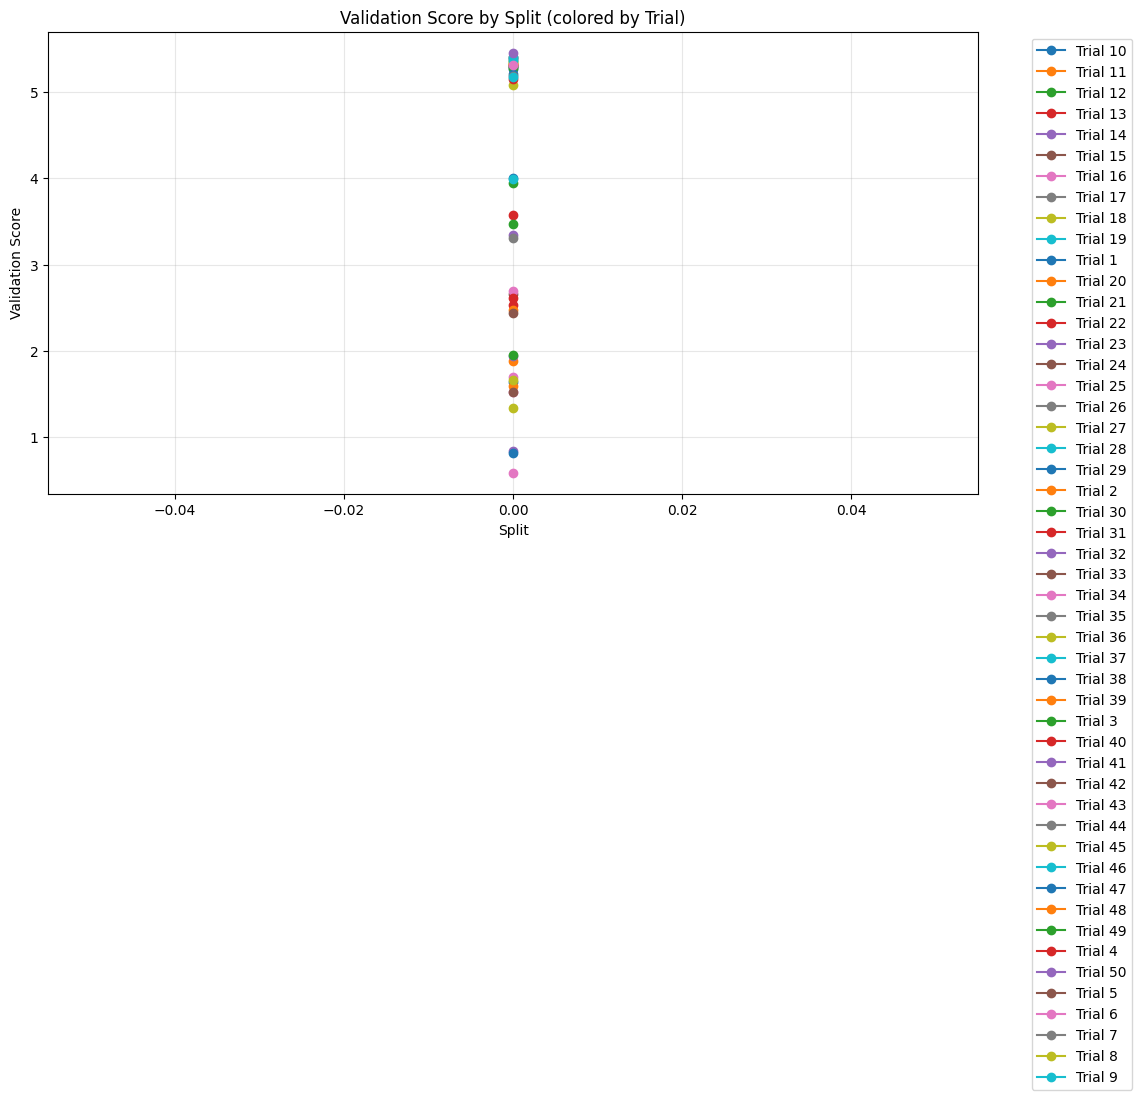

In [7]:
from hp_tuning_utils import plot_validation_score_by_split

plot_validation_score_by_split(df)


In [8]:
from hp_tuning_utils import select_and_save_best_hp


best_trial, best_data = select_and_save_best_hp(df, base_logdir)


Best trial: 43 (avg validation score: 0.5904)

Hyperparameters:
  dropout: 0.3
  l2_regularization: 9.149211726125688e-05
  learning_rate: 0.004695664617600049
  feature_dropout: 0
  output_regularization: 0.05264879146480235

Best hyperparameters saved to: ./hp_tuning_correlated_nonlinear\best_hp.json
